### Mount Google Drive

To access files stored in your Google Drive, you first need to mount it. This will prompt you to authorize Colab to access your Google Drive files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load Data from Google Drive

Once Google Drive is mounted, your files will be accessible under `/content/drive/MyDrive/`. You can replace `your_file.csv` with the actual path to your data file in Google Drive and adjust the loading function (`pd.read_csv`, `pd.read_excel`, etc.) based on your file type.

In [2]:
import pandas as pd
import os

# Define la ruta del archivo TXT en Google Drive
file_path = '/content/drive/MyDrive/JP_PUCP/MINITALLER_SOCIALES/Chat_WhatsApp_Individual.txt'

# Leer el archivo directamente
with open(file_path, 'r', encoding='utf-8') as file:
    lineas = file.readlines()

print(f"Archivo cargado correctamente")
print(f"Total de líneas: {len(lineas)}")
print(f"\nPrimeras 5 líneas:")
for i in range(min(5, len(lineas))):
    print(f"{i+1}: {lineas[i][:100]}...")

Archivo cargado correctamente
Total de líneas: 161546

Primeras 5 líneas:
1: 1/2/2024, 11:36 p. m. - Los mensajes y las llamadas están cifrados de extremo a extremo. Solo las pe...
2: 1/2/2024, 11:36 p. m. - ‎+51 981 355 642 cambió su número de teléfono. Actualmente, te estás comunic...
3: 2/2/2024, 6:28 a. m. - Los mensajes y las llamadas están cifrados de extremo a extremo. Solo las per...
4: 2/2/2024, 6:28 a. m. - Sayu Cuchis<3: Buenos días cuchís
...
5: 2/2/2024, 8:06 a. m. - Erick: Buenos días cuchis
...


## Plan de Procesamiento de Lenguaje Natural (NLP)

Seguiremos los siguientes pasos para analizar tu chat de WhatsApp:

1.  **Parseo y Anominización**: Extraer fecha, remitente y mensaje de cada línea del chat, y anonimizar los nombres de los remitentes.
2.  **Limpieza de Texto**: Eliminar caracteres no deseados, enlaces y emojis, y normalizar el texto (e.g., a minúsculas).
3.  **Tokenización y Eliminación de Stop Words**: Dividir los mensajes en palabras y remover palabras comunes (stop words) en español.
4.  **Nube de Palabras (Word Clouds)**: Visualizar las palabras más frecuentes.
5.  **Cálculo TF-IDF**: Identificar palabras clave que son importantes en el chat.
6.  **Análisis de Sentimientos**: Determinar el tono emocional de los mensajes.
7.  **Evolución de Tópicos por Año**: Analizar cómo los temas de conversación cambian con el tiempo.

### Paso 1: Parseo de Mensajes y Anominización

El primer paso es estructurar los datos del chat. Esto implica extraer la fecha, la hora, el remitente y el contenido del mensaje de cada línea. Luego, asignaremos identificadores anónimos a cada remitente.

In [5]:
import re
import pandas as pd

# Lista para almacenar los mensajes parseados
mensajes_parseados = []

# Diccionario para anonimizar nombres
remitentes_anonimos = {}
anon_counter = 1

def parsear_linea_whatsapp(linea):
    # Expresión regular para capturar fecha, hora, remitente y mensaje
    # Se ajusta para manejar el formato 'DD/MM/YYYY, HH:MM - Sender: Message' y variaciones
    # Se asume que una línea que no coincide con el patrón es una continuación del mensaje anterior

    # Patrón para mensajes normales (con remitente)
    match_remitente = re.match(r'^(\d{1,2}/\d{1,2}/\d{2,4}, \d{1,2}:\d{2}\s*(?:a\.\s*m\.\s*|p\.\s*m\.\s*)?) - ([^:]+): (.*)$', linea, re.DOTALL)
    # Patrón para mensajes del sistema (sin remitente explícito después de la fecha y hora)
    match_sistema = re.match(r'^(\d{1,2}/\d{1,2}/\d{2,4}, \d{1,2}:\d{2}\s*(?:a\.\s*m\.\s*|p\.\s*m\.\s*)?) - (.*)$', linea, re.DOTALL)

    if match_remitente:
        fecha_hora = match_remitente.group(1).strip()
        remitente_original = match_remitente.group(2).strip()
        mensaje = match_remitente.group(3).strip()
    elif match_sistema:
        fecha_hora = match_sistema.group(1).strip()
        remitente_original = 'Sistema'
        mensaje = match_sistema.group(2).strip()
    else:
        # Si la línea no coincide, se asume que es una continuación del mensaje anterior
        if mensajes_parseados:
            mensajes_parseados[-1]['mensaje'] += '\n' + linea.strip()
        return None

    # Anonimizar remitente
    global anon_counter
    if remitente_original not in remitentes_anonimos:
        remitentes_anonimos[remitente_original] = f'Anonimo_{anon_counter}'
        anon_counter += 1
    remitente_anonimo = remitentes_anonimos[remitente_original]

    return {
        'fecha_hora': fecha_hora,
        'remitente_original': remitente_original,
        'remitente_anonimo': remitente_anonimo,
        'mensaje': mensaje
    }

# Procesar cada línea del archivo
for linea in lineas:
    parsed = parsear_linea_whatsapp(linea)
    if parsed:
        mensajes_parseados.append(parsed)

# Convertir a DataFrame de pandas para facilitar el análisis
df_chat = pd.DataFrame(mensajes_parseados)

# Mostrar las primeras filas del DataFrame
display(df_chat.head())

print(f"Total de mensajes parseados: {len(df_chat)}")
print("Remitentes anonimizados:")
for original, anon in remitentes_anonimos.items():
    print(f"  {original} -> {anon}")

,fecha_hora,remitente_original,remitente_anonimo,mensaje
0,"1/2/2024, 11:36 p. m.",Sistema,Anonimo_1,Los mensajes y las llamadas están cifrados de ...
1,"1/2/2024, 11:36 p. m.",Sistema,Anonimo_1,‎+51 981 355 642 cambió su número de teléfono....
2,"2/2/2024, 6:28 a. m.",Sistema,Anonimo_1,Los mensajes y las llamadas están cifrados de ...
3,"2/2/2024, 6:28 a. m.",Sayu Cuchis<3,Anonimo_2,Buenos días cuchís
4,"2/2/2024, 8:06 a. m.",Erick,Anonimo_3,Buenos días cuchis


Total de mensajes parseados: 159989
Remitentes anonimizados:
  Sistema -> Anonimo_1
  Sayu Cuchis<3 -> Anonimo_2
  Erick -> Anonimo_3


### Paso 2: Limpieza de Texto

Ahora vamos a limpiar el texto de los mensajes. Esto incluye:
- Eliminar URLs
- Eliminar emojis
- Convertir todo el texto a minúsculas

In [12]:
import re
import emoji

def limpiar_texto(texto):
    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)

    # Eliminar emojis
    texto = emoji.demojize(texto) # Convertir emojis a texto (e.g., :smile:)
    texto = re.sub(r':[a-zA-Z0-9_\-]+:', '', texto) # Eliminar los códigos de emoji

    # Eliminar la frase 'multimedia omitido'
    texto = re.sub(r'multimedia omitido', '', texto)

    # Eliminar otros caracteres no deseados (opcional, se puede expandir)
    # Por ejemplo, para eliminar caracteres que no sean letras, números o espacios:
    # texto = re.sub(r'[^a-zA-Z0-9\s]', '', texto)

    return texto

# Aplicar la función de limpieza a la columna 'mensaje'
df_chat['mensaje_limpio'] = df_chat['mensaje'].apply(limpiar_texto)

# Mostrar las primeras filas del DataFrame con el mensaje limpio
display(df_chat[['mensaje', 'mensaje_limpio']].head())

,mensaje,mensaje_limpio
0,Los mensajes y las llamadas están cifrados de ...,los mensajes y las llamadas están cifrados de ...
1,‎+51 981 355 642 cambió su número de teléfono....,‎+51 981 355 642 cambió su número de teléfono....
2,Los mensajes y las llamadas están cifrados de ...,los mensajes y las llamadas están cifrados de ...
3,Buenos días cuchís,buenos días cuchís
4,Buenos días cuchis,buenos días cuchis


### Paso 3: Tokenización y Eliminación de Stop Words

Vamos a tokenizar los mensajes (dividir el texto en palabras) y eliminar las "stop words" (palabras muy comunes que no aportan mucho significado, como "el", "la", "un", etc.) en español.

In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descargar las stop words y el tokenizador 'punkt' y 'punkt_tab'
# Es buena práctica descargarlos al inicio para asegurar que estén disponibles
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Aseguramos la descarga de 'punkt_tab'

stopwords_es = set(stopwords.words('spanish'))

def remover_stopwords(texto):
    # Tokenizar el texto
    palabras = word_tokenize(texto, language='spanish')
    # Convertir a minúsculas y remover stop words
    palabras_filtradas = [palabra for palabra in palabras if palabra.lower() not in stopwords_es and palabra.isalpha()]
    return " ".join(palabras_filtradas)

# Aplicar la función a la columna 'mensaje_limpio'
df_chat['mensaje_procesado'] = df_chat['mensaje_limpio'].apply(remover_stopwords)

# Mostrar las primeras filas del DataFrame con el mensaje procesado
display(df_chat[['mensaje_limpio', 'mensaje_procesado']].head())

,mensaje_limpio,mensaje_procesado
0,los mensajes y las llamadas están cifrados de ...,mensajes llamadas cifrados extremo extremo sol...
1,‎+51 981 355 642 cambió su número de teléfono....,cambió número teléfono actualmente comunicando...
2,los mensajes y las llamadas están cifrados de ...,mensajes llamadas cifrados extremo extremo sol...
3,buenos días cuchís,buenos días cuchís
4,buenos días cuchis,buenos días cuchis


### Paso 4: Nube de Palabras (Word Clouds)

Ahora generaremos una nube de palabras para visualizar los términos más frecuentes en los mensajes procesados. Esto nos dará una idea rápida de los temas dominantes en el chat.

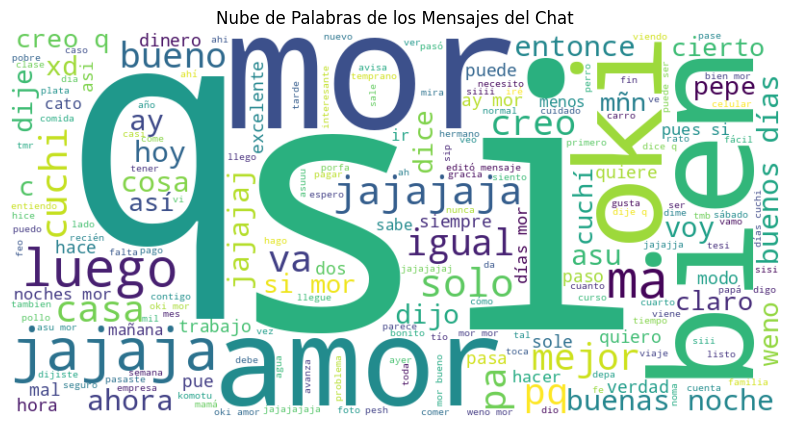

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todos los mensajes procesados en una sola cadena de texto
texto_completo = " ".join(df_chat['mensaje_procesado'].dropna().tolist())

# Generar la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_completo)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de los Mensajes del Chat')
plt.show()

### Paso 5: Cálculo TF-IDF

El TF-IDF (Term Frequency-Inverse Document Frequency) es una medida numérica que refleja la importancia de una palabra en un documento en relación con una colección de documentos. Nos ayudará a identificar palabras clave que son significativas en el chat.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Crear un objeto TfidfVectorizer
# max_features puede ser útil para limitar el número de palabras a considerar
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Ajustar y transformar los mensajes procesados
tfidf_matrix = tfidf_vectorizer.fit_transform(df_chat['mensaje_procesado'].dropna())

# Obtener los nombres de las características (palabras)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calcular la suma de los scores TF-IDF para cada palabra
somos_tfidf = tfidf_matrix.sum(axis=0)

# Crear un DataFrame para visualizar las palabras más importantes
words_tfidf_df = pd.DataFrame({'word': feature_names, 'tfidf_score': somos_tfidf.tolist()[0]})
words_tfidf_df = words_tfidf_df.sort_values(by='tfidf_score', ascending=False)

print("Top 20 palabras por score TF-IDF:")
display(words_tfidf_df.head(20))

Top 20 palabras por score TF-IDF:


,word,tfidf_score
3051,mor,5505.477139
4303,si,3584.339764
507,bien,1974.450206
3244,oki,1803.704388
225,amor,1589.106869
413,ay,1530.261288
2440,jajaja,1475.094433
2444,jajajaja,1228.971468
1200,cuchis,1162.933436
347,asu,1059.743803


### Paso 6: Frecuencia de Mensajes a lo largo del Tiempo

Vamos a visualizar cómo la frecuencia de mensajes ha evolucionado con el tiempo. Esto nos puede dar información sobre periodos de mayor o menor actividad en el chat.

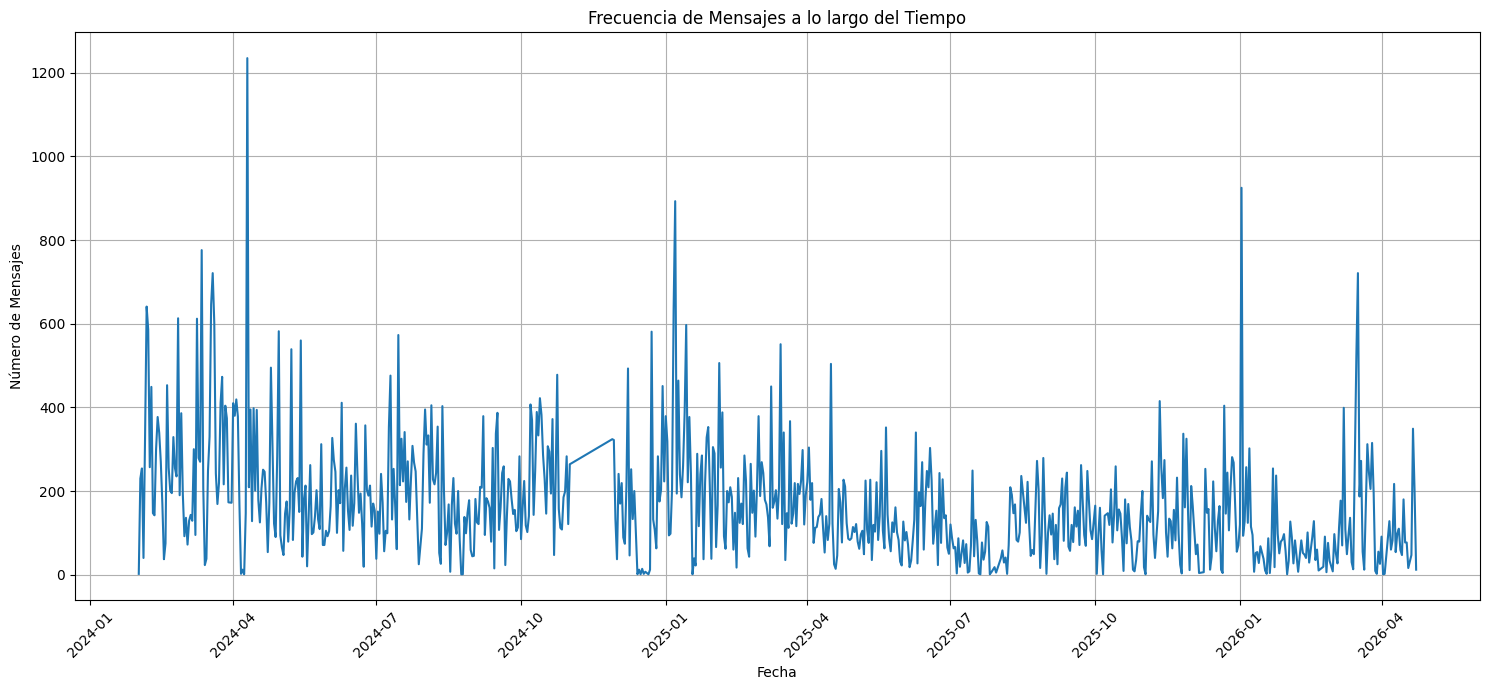

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir la columna 'fecha_hora' a tipo datetime
# Se ajusta el formato para que pandas lo parse correctamente, especialmente con 'a. m.' y 'p. m.'
df_chat['fecha_hora'] = pd.to_datetime(df_chat['fecha_hora'], format='%d/%m/%Y, %I:%M\u202fp.\u202fm.', errors='coerce')

# Eliminar filas con fechas no válidas si las hay (por el errors='coerce')
df_chat.dropna(subset=['fecha_hora'], inplace=True)

# Extraer la fecha (sin la hora) para agrupar por día
df_chat['fecha'] = df_chat['fecha_hora'].dt.date

# Contar la frecuencia de mensajes por día
mensajes_por_dia = df_chat['fecha'].value_counts().sort_index()

# Convertir a DataFrame para facilitar el plotting con seaborn
mensajes_por_dia_df = mensajes_por_dia.reset_index()
mensajes_por_dia_df.columns = ['Fecha', 'Numero_Mensajes']
mensajes_por_dia_df['Fecha'] = pd.to_datetime(mensajes_por_dia_df['Fecha'])

# Crear el gráfico de líneas
plt.figure(figsize=(15, 7))
sns.lineplot(x='Fecha', y='Numero_Mensajes', data=mensajes_por_dia_df)
plt.title('Frecuencia de Mensajes a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Número de Mensajes')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Actividad Diaria por Remitente

Vamos a analizar qué remitentes tienen mayor actividad diaria en el chat. Agruparemos los mensajes por fecha y remitente, y luego visualizaremos los remitentes más activos.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la frecuencia de mensajes por día y por remitente anónimo
mensajes_por_dia_remitente = df_chat.groupby(['fecha', 'remitente_anonimo']).size().reset_index(name='Numero_Mensajes')

# Encontrar al remitente con la mayor cantidad de mensajes en cada día
idx = mensajes_por_dia_remitente.groupby(['fecha'])['Numero_Mensajes'].transform('max') == mensajes_por_dia_remitente['Numero_Mensajes']
remitente_mas_activo_por_dia = mensajes_por_dia_remitente[idx].sort_values(by='fecha')

# Si hay empates, toma el primero (o considera una forma más sofisticada si es necesario)
remitente_mas_activo_por_dia = remitente_mas_activo_por_dia.drop_duplicates(subset=['fecha'], keep='first')

display(remitente_mas_activo_por_dia.head())

,fecha,remitente_anonimo,Numero_Mensajes
0,2024-02-01,Anonimo_1,2
2,2024-02-02,Anonimo_3,129
4,2024-02-03,Anonimo_3,129
5,2024-02-04,Anonimo_2,20
8,2024-02-05,Anonimo_3,196


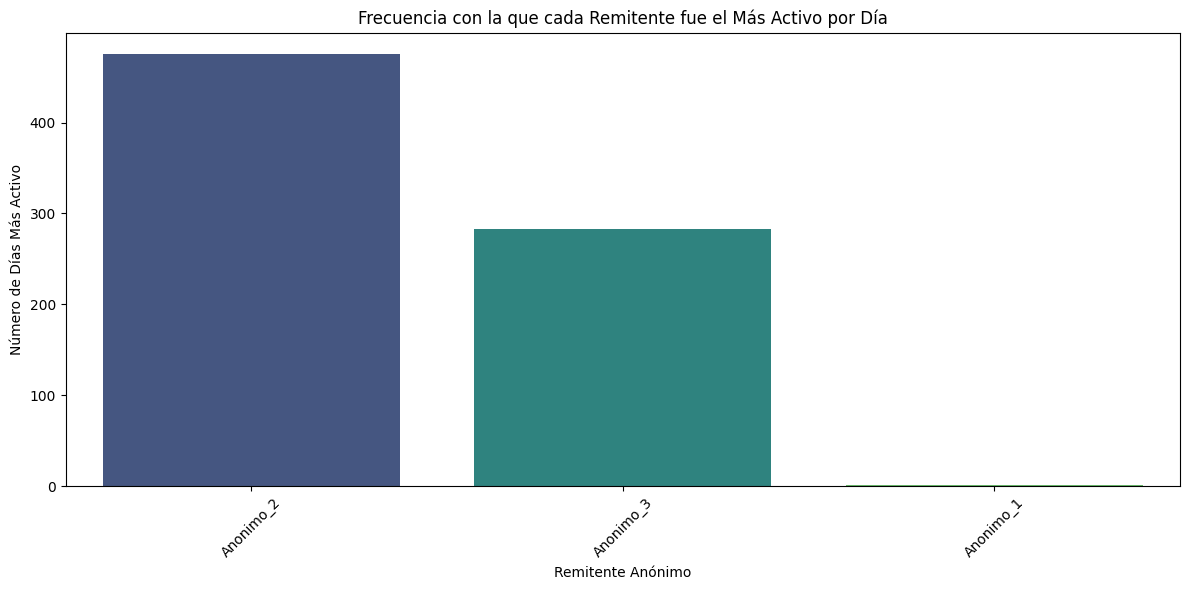

In [20]:
# Para una mejor visualización, podemos contar cuántas veces cada remitente fue el más activo
conteo_remitentes_activos = remitente_mas_activo_por_dia['remitente_anonimo'].value_counts().reset_index()
conteo_remitentes_activos.columns = ['Remitente', 'Veces_Mas_Activo']

plt.figure(figsize=(12, 6))
sns.barplot(x='Remitente', y='Veces_Mas_Activo', hue='Remitente', data=conteo_remitentes_activos, palette='viridis', legend=False)
plt.title('Frecuencia con la que cada Remitente fue el Más Activo por Día')
plt.xlabel('Remitente Anónimo')
plt.ylabel('Número de Días Más Activo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Este gráfico muestra qué remitentes son los más activos de forma consistente a lo largo de los días de la conversación.

### Paso 7: Análisis de Sentimientos

Ahora realizaremos un análisis de sentimientos para comprender el tono emocional de los mensajes. Utilizaremos la librería `textblob-es` para determinar la polaridad (positivo, negativo, neutro) de cada mensaje.

In [26]:
# Instalar la librería transformers
!pip install transformers

from transformers import pipeline
import pandas as pd

# Cargar un modelo de análisis de sentimientos pre-entrenado para español
# Usaremos un modelo conocido por su buen rendimiento en español, como los de 'cardiffnlp'
sentiment_pipeline = pipeline("sentiment-analysis", model="finiteautomata/beto-sentiment-analysis")

# Función para obtener el sentimiento de un mensaje usando el modelo de transformers
def get_sentiment_transformers(text):
    if not text.strip(): # Evitar analizar textos vacíos
        return None
    # Truncar el texto si supera la longitud máxima del modelo (512 tokens)
    # Algunos modelos pueden tener diferentes límites, 512 es un valor común.
    # El pipeline de transformers ya maneja la tokenización internamente, pero podemos pre-truncar
    # para evitar errores explícitos de longitud si el modelo no lo hace automáticamente de forma silenciosa.
    # Forzar la truncación a un valor seguro antes de enviarlo al pipeline.
    truncated_text = ' '.join(text.split()[:400]) # Aproximadamente 400 palabras for 512 tokens, adjust if needed

    # El pipeline retorna una lista de diccionarios, tomamos el primer resultado
    result = sentiment_pipeline(truncated_text)[0]
    label = result['label']
    score = result['score']

    # Mapear las etiquetas a una polaridad numérica (ej. -1 para NEG, 0 para NEU, 1 para POS)
    if label == 'NEG':
        return -score
    elif label == 'POS':
        return score
    else: # NEU
        return 0

# Tomar una muestra aleatoria de 1000 mensajes para un análisis más rápido
# Asegurarse de que 'mensaje_procesado' no tenga valores nulos antes de muestrear si es posible
sample_size = 1000
df_chat_sample = df_chat.dropna(subset=['mensaje_procesado']).sample(n=min(sample_size, len(df_chat)), random_state=42)

# Aplicar la función a la columna 'mensaje_procesado' de la muestra
df_chat_sample['sentimiento'] = df_chat_sample['mensaje_procesado'].apply(get_sentiment_transformers)

# Clasificar el sentimiento en categorías (ajustar umbrales si es necesario)
def classify_sentiment(polarity):
    if polarity is None: # Manejar valores None
        return 'Neutro'
    if polarity > 0.3: # Umbral para positivo (puede ajustarse)
        return 'Positivo'
    elif polarity < -0.3: # Umbral para negativo (puede ajustarse)
        return 'Negativo'
    else:
        return 'Neutro'

df_chat_sample['sentimiento_clase'] = df_chat_sample['sentimiento'].apply(classify_sentiment)

# Mostrar la distribución de sentimientos de la muestra
print("Distribución de Sentimientos (Muestra de {} mensajes):".format(len(df_chat_sample)))
display(df_chat_sample['sentimiento_clase'].value_counts())

# Mostrar las primeras filas con el sentimiento de la muestra
display(df_chat_sample[['mensaje_procesado', 'sentimiento', 'sentimiento_clase']].head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: finiteautomata/beto-sentiment-analysis
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Distribución de Sentimientos (Muestra de 1000 mensajes):


,count
sentimiento_clase,
Neutro,773
Positivo,132
Negativo,95


,mensaje_procesado,sentimiento,sentimiento_clase
147630,,NaN,Neutro
66340,anda mercado cómprate filete carne chancho,0.893918,Positivo
83629,así,0.412759,Positivo
135110,puedo llamar rato,0.000000,Neutro
129911,amor,0.997709,Positivo


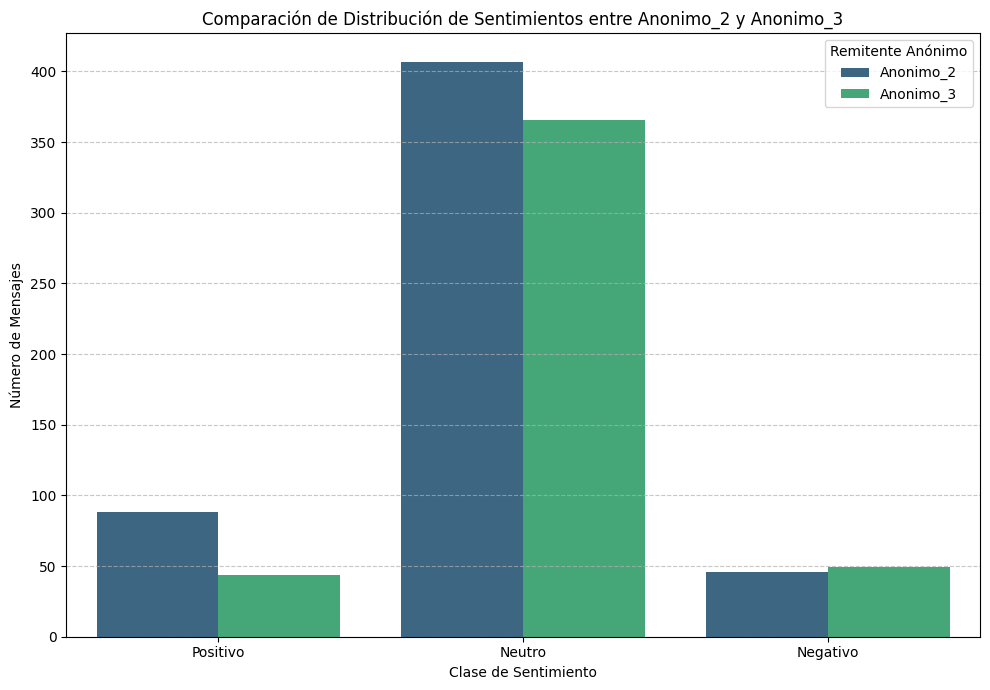

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame de muestra para 'Anonimo_2' y 'Anonimo_3'
df_comparacion = df_chat_sample[df_chat_sample['remitente_anonimo'].isin(['Anonimo_2', 'Anonimo_3'])]

plt.figure(figsize=(10, 7))
sns.countplot(x='sentimiento_clase', hue='remitente_anonimo', data=df_comparacion, palette='viridis', order=['Positivo', 'Neutro', 'Negativo'])
plt.title('Comparación de Distribución de Sentimientos entre Anonimo_2 y Anonimo_3')
plt.xlabel('Clase de Sentimiento')
plt.ylabel('Número de Mensajes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Remitente Anónimo')
plt.tight_layout()
plt.show()

### Paso 8: Evolución de Tópicos por Año

Analicemos cómo los temas de conversación han cambiado a lo largo del tiempo. Para esto, utilizaremos Latent Dirichlet Allocation (LDA), un método de modelado de tópicos, que nos permitirá identificar los temas principales por cada año en el chat. Los resultados nos mostrarán las palabras más representativas de cada tópico anualmente.

In [30]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Asegurarse de que la columna 'fecha_hora' es de tipo datetime y extraer el año
# Esto ya se hizo en pasos anteriores, pero lo volvemos a asegurar para este análisis
#df_chat['fecha_hora'] = pd.to_datetime(df_chat['fecha_hora'], format='%d/%m/%Y, %I:%M\u202fp.\u202fm.', errors='coerce')
df_chat['year'] = df_chat['fecha_hora'].dt.year

# Filtrar mensajes nulos en 'mensaje_procesado' antes de agrupar
df_chat_filtered = df_chat.dropna(subset=['mensaje_procesado'])

# Obtener los años únicos en el dataset
years = sorted(df_chat_filtered['year'].unique())

# Función para mostrar los tópicos
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Tópico {topic_idx + 1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
    print("\n")

# Parámetros para LDA
no_topics = 5  # Número de tópicos a identificar
no_top_words = 10 # Número de palabras clave por tópico

print("\n--- Análisis de Tópicos por Año ---\n")

for year in years:
    print(f"Analizando el año: {year}")
    # Filtrar mensajes por año
    df_year = df_chat_filtered[df_chat_filtered['year'] == year]

    if len(df_year) < 100: # Se requiere un mínimo de mensajes para un análisis significativo
        print(f"  Pocos mensajes en {year} ({len(df_year)}). Saltando análisis de tópicos.\n")
        continue

    # Crear la matriz de documentos-términos
    # Utilizamos CountVectorizer ya que los stopwords ya fueron eliminados y el texto está tokenizado
    tf_vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
    tf = tf_vectorizer.fit_transform(df_year['mensaje_procesado'])
    tf_feature_names = tf_vectorizer.get_feature_names_out()

    # Aplicar LDA
    lda_model = LatentDirichletAllocation(n_components=no_topics, max_iter=10,
                                         learning_method='online', learning_offset=50.,
                                         random_state=0)
    lda_model.fit(tf)

    # Mostrar los tópicos para el año actual
    display_topics(lda_model, tf_feature_names, no_top_words)



--- Análisis de Tópicos por Año ---

Analizando el año: 2024
Tópico 1:
luego jajajaja mas xd modo dos verdad puedo siempre hora
Tópico 2:
si amor voy así pa pq ir vas soles ser
Tópico 3:
mor jajaja creo quiero mejor entonces jajajaj mñn dije hacer
Tópico 4:
bien cuchis ay weno ahora solo buenas asu casa noches
Tópico 5:
bueno oki pues igual dijo excelente claro hoy iré vamos


Analizando el año: 2025
Tópico 1:
mor amor ay weno vas hoy dinero hora comer avisas
Tópico 2:
jajaja jajajaja buenas noches dije entonces jajajaj dijo excelente asi
Tópico 3:
si creo bueno pues pepe xd mal soles tmb siempre
Tópico 4:
oki casa ahora asu igual cosas cierto pa mensaje puedo
Tópico 5:
bien solo quiero voy luego mñn mejor hacer mas ir


Analizando el año: 2026
Tópico 1:
igual voy pq entonces va jajajaj verdad cosas agua hacer
Tópico 2:
amor ay creo pues dijo dice cierto tiempo dios oye
Tópico 3:
solo jajaja vas cato claro sueño dos cuidado mñn quiero
Tópico 4:
si oki bien casa ahora luego moto mejor 

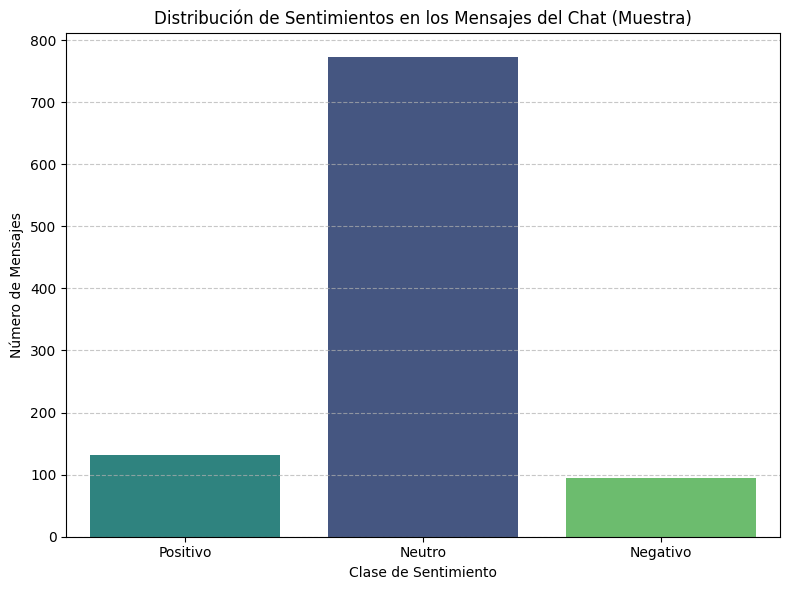

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar la distribución de sentimientos
plt.figure(figsize=(8, 6))
sns.countplot(x='sentimiento_clase', data=df_chat_sample, palette='viridis', order=['Positivo', 'Neutro', 'Negativo'], hue='sentimiento_clase', legend=False)
plt.title('Distribución de Sentimientos en los Mensajes del Chat (Muestra)')
plt.xlabel('Clase de Sentimiento')
plt.ylabel('Número de Mensajes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()